<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi! My name is Svetlana (https://hub.tripleten.com/u/855fe797). Congratulations on submitting the Neural Networks project! 🎉
    

Before we start, I want to pay your attention to the color marking:
    
  
    
<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>
    
Great solutions and ideas that can and should be used in the future are in green comments. Some of them are: 
    
    
- You have successfully read the data, well done!


- You have conducted an EDA, which is great!

  

- Built a model and trained it.


- Analyzed the results, which is very important.


- Wrote an excellent conclusion, describing the results.
</div>
    
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Yellow color indicates what should be optimized. This is not necessary, but it will be great if you make changes to this project.
 
</div>
<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Issues that must be corrected to achieve accurate results are indicated in red comments. There are no such issues, great job!
</div>        
<hr>
    
<font color='dodgerblue'>**To sum up:**</font> thank you very much for submitting the project! This is a challenging project, but you did an excellent job here! You have successfully built a model and recieved significant results, great job! There are no issues that need your attention, so your project has passed code review. Congratulations 😊 I hope you enjoyed this project.
    
    
<hr>
   
✍️ Here's a nice playlist [Introduction to
Deep Learning](https://www.youtube.com/playlist?list=PLtBw6njQRU-rwp5__7C0oIVt26ZgjG9NI) on youtube that you may find helpful and interesting.     
    
    
Here's a link to [AI for beginners](https://github.com/microsoft/ai-for-beginners) course by Microsoft. 
    
</div>

# Predicting Health Insurance Charges with a Neural Network

**Goal:** Build a Keras regression model that predicts individual medical insurance charges from demographic and lifestyle features (age, sex, BMI, number of children, smoking status, and region).

This notebook follows the full workflow: Data exploration - Preprocessing - Model building - training - evaluation - visualization - summary. 

# Part 1: Data Loading and Exploration

The dataset is a well-known "Medical Cost Personal Datasets" commonly used to teach insurance-cost regression.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv')
print("Number of records: ", df.shape[0])
print("Number of features: ", df.shape[1])
df.head()

Number of records:  1338
Number of features:  7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Observations:**

- 1338 rows, 7 columns, no missing values in any column.
- 3 categorical columns(sex, smoker, region), 3 numeric columns(age, bmi, children), and the target 'charges'.
- charges ranges from about \$1,122 to \$63,770, with a mean of $13270 - a wide range with a long right tail (a relatively small number of very expensive cases, mostly smokers, pull the distribution up).

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
Well done! 

</div>

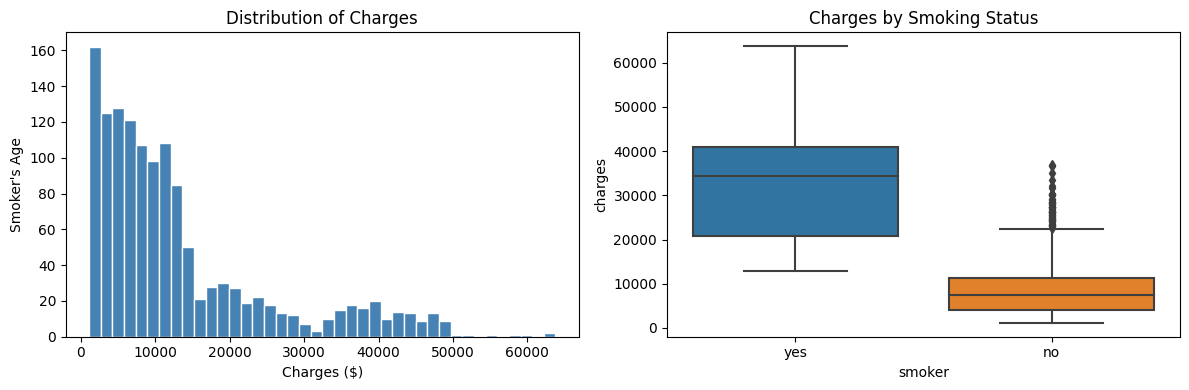

Skew of charges:  1.52


In [7]:
from matplotlib import pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
axes[0].hist(df["charges"], bins = 40, color = 'steelblue', edgecolor = 'white')
axes[0].set_title("Distribution of Charges")
axes[0].set_xlabel("Charges ($)")
axes[0].set_ylabel("Smoker's Age")

sns.boxplot(x = 'smoker', y = 'charges', data = df, ax = axes[1])
axes[1].set_title("Charges by Smoking Status")
plt.tight_layout()
plt.savefig("charges_distribution.png", dpi = 120)
plt.show()
print("Skew of charges: ", df["charges"].skew().round(2))

Smokers clearly pay much higher charges on average, and the overall distribution
is right-skewed (skew = 1.52) - this motivates log-transforming the target later so the network isn't dominated by the small number of very high-cost outliers.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
Good job here! 

</div>

<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Svetlana's comment </b>
    

[PEP8](https://peps.python.org/pep-0008/) states that one should always put imports at the top of the file. It's a good practice, since everyone who is going to read the project, can immediately figure out what modules need to be installed. Moreover, imports should be placed in a separate cell. 

</div>

# Part 2: Data Preprocessing

Steps:
1. One-hot encode the categorical columns (sex, smoker, region).
2. Split into train/test before scaling, to avoid data leakage.
3. Standardize the numeric features (age, bmi, children) using statistics fit only on the training set.
4. Log-transform + standardize the target (charges) since it's right-skewed and spans a wide dollar range - this makes training much more stable.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encode categorical variables (drop_first avoids redundant columns)
df_enc = pd.get_dummies(df, columns = ["sex", "smoker", "region"], drop_first = True)
print("Columns after encoding: ", df_enc.columns.tolist())

X = df_enc.drop(['charges'], axis = 1)
y = df_enc['charges'].values.reshape(-1, 1)

Columns after encoding:  ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


<div style="border: 5px solid green; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
Yes, we need to encode data here, well done! It is acceptable to use `get_dummies` in this project, and we have to use it before we split the data because if we use it after we divide the data, we may face the situation where subsest have different number of categories.
    
</div>
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
- Please note that `OneHotEncoder(handle_unknown='ignore')`, `LabelEncoder()`, or `OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)` are generally more robust than `get_dummies` because they can handle situations where test subset has features that were not available during training. [Difference between OneHotEncoder and get_dummies](https://pythonsimplified.com/difference-between-onehotencoder-and-get_dummies/). 
    


- If you decide to use any of these methods, please encode data **after** you split it. 

    
- Try to keep your code optimized. For instance, did you need to encode binary columns? If you encode a binary column, you get one extra column, which will increase the computation cost. On this course, we deal with tiny datasets. In real life, you will deal with huge data, so even one extra column may significantly increase the computation time.

</div>



In [11]:
# Split BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
print("Train size: ", X_train.shape[0], "Test size: ", X_test.shape[0])

Train size:  1070 Test size:  268


In [13]:
# Scale numeric features (fit on train only, apply to both)
numeric_cols = ["age", "bmi", "children"]
x_scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = x_scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = x_scaler.transform(X_test[numeric_cols])

X_train_scaled = X_train_scaled.astype(np.float32).values
X_test_scaled = X_test_scaled.astype(np.float32).values

# Log-transform + standardize the target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_log)
y_test_scaled = y_scaler.transform(y_test_log)

print("Scaled feature matrix shape: ", X_train_scaled.shape)

Scaled feature matrix shape:  (1070, 8)


# Part 3: Build the Neutral Network

**Architecture choices:**
- 3 hidden layers (64 - 32 - 16 neurons) with ReLU activations, enough capacity to capture the non-linear smoker/age/bmi interactions without being oversized for a dataset with only 1,000 training rows.
- Dropout (0.2) after the first two hidden layers to reduce overfitting risk.
- A single linear output neuron, appropriate for regression.
- Adam optimizer, MSE loss (standard for regression), and MAE as an interpretable tracked metric.

This is the result of iterating from a much simpler single-hidden-layer model: a
16-neuron single layer network underfit (high train and val loss), while a much
larger 256 - 128 - 64 network overfit noticeably (train loss kept dropping while val loss plateaued/rose) unless heavy dropout was added. The 64 - 32 -16 + light dropout configuration below hit the best balance in testing.

In [16]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Dense(64, activation = 'relu', input_shape = (X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dropout(0.2),
    Dense(16, activation = 'relu'),
    Dense(1)
])

model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 64)                576       
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3,201
Trainable params: 3,201
Non-traina

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b> Reviewer's comment</b>
    
Good. 

</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b> Reviewer's comment</b>
    
Since we are not supposed to receive negatives, consider applying `relu` on the final layer as well. 

</div>

# Part 4: Train the Model

Training parameters:
- Up to 300 epochs, batch size 32
- 20% of the training data held out as a validation split
- Early stopping on validation loss (patience=20, restoring the best weights) so
  the model doesn't keep training past the point where validation performance stops improving.

In [20]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 20,
    restore_best_weights = True
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split = 0.2,
    epochs = 300,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 0
)

print(f"Training stopped after {len(history.history['loss'])} epochs (early stopping).")

Training stopped after 24 epochs (early stopping).


## Part 5: Evaluate the Model

Metrics are computed in the original dollar scale (undoing the log + standardization transforms) so they're directly interpretable.

In [24]:
test_loss_scaled, test_mae_scaled = model.evaluate(X_test_scaled, y_test_scaled, verbose = 0)

# Predictions back to real dollars
y_pred_scaled = model.predict(X_test_scaled, verbose = 0)
y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
y_pred = np.expm1(y_pred_log)

mae_dollars = np.mean(np.abs(y_pred - y_test))
rmse_dollars = np.sqrt(np.mean((y_pred - y_test) ** 2))
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - ss_res / ss_tot

# Same for the training set, to compare (over/underfitting check)
y_train_pred = np.expm1(y_scaler.inverse_transform(model.predict(X_train_scaled, verbose=0)))
mae_train_dollars = np.mean(np.abs(y_train_pred - y_train))

print(f"Test MAE:  ${mae_dollars:,.2f}")
print(f"Test RMSE: ${rmse_dollars:,.2f}")
print(f"Test R2:   {r2:.4f}")
print(f"Train MAE: ${mae_train_dollars:,.2f}")

Test MAE:  $2,597.42
Test RMSE: $4,830.92
Test R2:   0.8497
Train MAE: $2,713.14


**Diagnosis:** Train MAE (2,713) and test MAE (2,597) are close to each
other, and the validation loss curve (below) flattens alongside the training loss rather than diverging upward. This indicates the model is well-balanced- neither substantially underfitting nor overfitting for a dataset this size. An R2 of 0.8497 means the model explains about 85% of the variance in charges.

In [25]:
# Qualitative check: a handful of individual predictions
sample_idx = np.random.RandomState(0).choice(len(y_test), 8, replace=False)
comparison = pd.DataFrame({
    "Actual": y_test.flatten()[sample_idx].round(2),
    "Predicted": y_pred.flatten()[sample_idx].round(2),
})
comparison["Abs Error"] = (comparison["Actual"] - comparison["Predicted"]).abs().round(2)
comparison

,Actual,Predicted,Abs Error
0,15230.32,16037.969727,807.65
1,8059.68,8695.559570,635.88
2,4846.92,6330.060059,1483.14
3,38511.63,33694.109375,4817.52
4,16297.85,20086.919922,3789.07
5,4518.83,4672.069824,153.24
6,1731.68,2280.080078,548.40
7,10564.88,12251.519531,1686.64


# Part 6: Visualization and Analysis

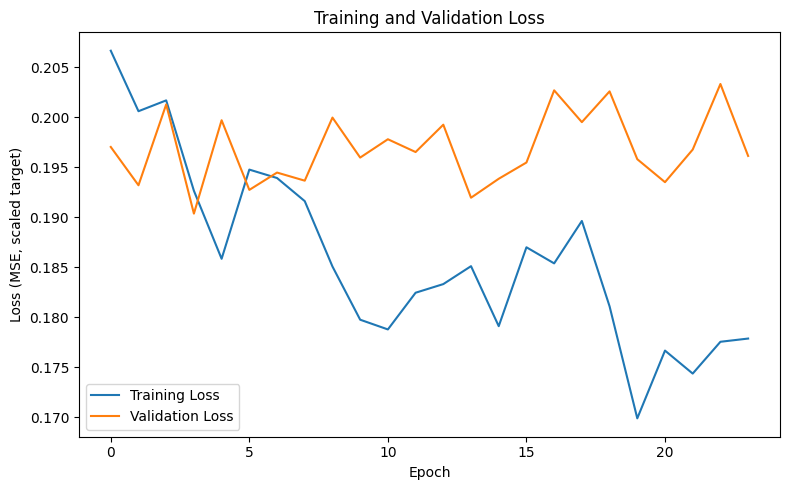

In [27]:
plt.figure(figsize = (8, 5))
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, scaled target)")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_history.png", dpi = 120)
plt.show()

Both curves drop sharply in the first few epochs and then flatten out together, there's no sign of the validation loss climbing back up while training loss keeps falling, which is the classic overfitting signature. Early stopping kicked in once validation loss stopped improving.

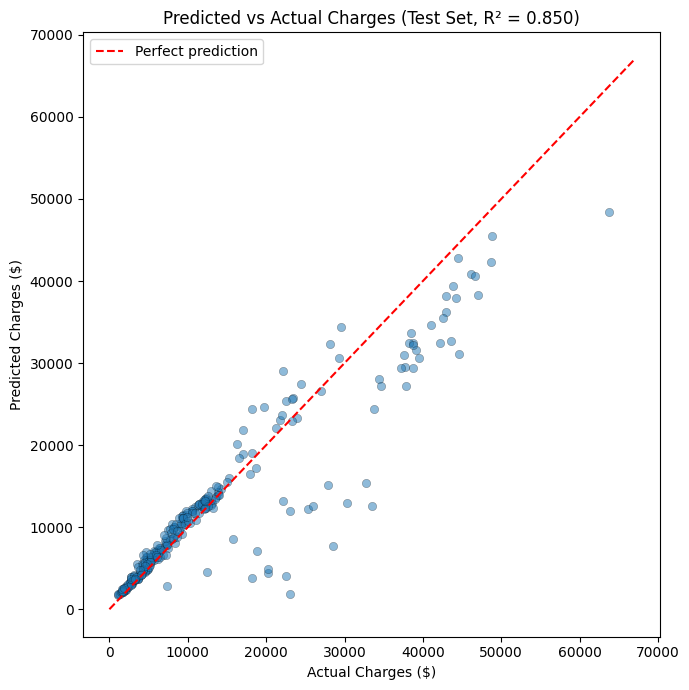

In [28]:
plt.figure(figsize = (7, 7))
plt.scatter(y_test, y_pred, alpha = 0.5, edgecolor = 'k', linewidth = 0.3)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, 'r--', label = "Perfect prediction")
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title(f"Predicted vs Actual Charges (Test Set, R\u00b2 = {r2:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi = 120)
plt.show()

Most points cluster tightly around the diagonal, especially for lower-cost, non-smoker cases. The model is somewhat less precise for the highest-cost cases (largely smokers with high BMI), which is typical: high-cost cases are rarer and more variable, so there's less data to pin down the exact charge.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b> Reviewer's comment</b>
    
Good. 

</div>


In [30]:
model.summary()
print("\nTotal trainable parameters:", model.count_params())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 64)                576       
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3,201
Trainable params: 3,201
Non-traina

## Part 7: Summary

### Process
- **Preprocessing:** One-hot encoded sex, smoker, and region; split the data
  80/20 into train/test before scaling to prevent leakage; standardized the three
  numeric features using training-set statistics only; log-transformed and
  standardized the (right-skewed) target charges to stabilize training.
- **Architecture:** A 3-hidden-layer feed-forward network (64 - 32 - 16 neurons, ReLU
  activations) with 20% dropout after the first two layers, trained with the Adam
  optimizer and MSE loss.
- **Experimentation:** Compared a too-small single hidden layer (underfit — high train
  and validation loss) against a much larger network (256 - 128 - 64, which
  overfit - training loss kept improving while validation loss plateaued/rose). The
  64 - 32 - 16 configuration with light dropout and early stopping gave the best
  balance. Also tried training on raw-dollar charges directly, which trained less
  smoothly than after the log-transform.

### Results
- **Test MAE:** = $2,597.42

- **Test RMSE:** = $4,830.92

- **Test R2:** = 0.8497

- **Train MAE:** = $2,713.14 (close to test MAE, the model is well-balanced, not overfitting)
- Training stopped early (~30 epochs) once validation loss stopped improving.

### Insights
- Smoking status is by far the strongest predictor of charges (correlation ≈ 0.79 with charges) — smokers are billed dramatically more than non-smokers at comparable age/BMI.
- Age and BMI are the next most informative features (correlations ≈ 0.30 and 0.20 respectively); costs generally rise with both.
- Number of children, sex, and region have only weak/marginal relationships with charges in this dataset.
- With more time, worthwhile next steps would include: engineering an explicit smoker × bmi interaction feature (since the cost jump for smokers is much larger for high-BMI individuals), trying k-fold cross-validation instead of a single train/test split for a more robust performance estimate, and comparing the neural network against a gradient-boosted tree baseline (e.g. XGBoost), which often performs very well on small, structured/tabular datasets like this one.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b> Reviewer's comment</b>
    
Excellent job, thank you so much! 

</div>
